### Creating single document to run all analysis and figure creation for in-situ data exploration of particle sinking phenomanon 

Nasuet Bloom data

Chukchi bivalve spawn

Tripos Seatrac data



## Utilities

In [28]:
### combine and filter dataframes


from pathlib import Path
import pandas as pd

def combine_csvs_with_filename(directory):
    """
    Combine all CSV files in a directory into one DataFrame.
    Adds a 'FileName' column containing the source filename.
    """
    dfs = []

    for file in Path(directory).glob("*.csv"):
        df = pd.read_csv(file)
        df["FileName"] = file.name
        dfs.append(df)

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

In [29]:
def filter_class(class_name,master_df, alpha):
    """
    Return rows where any column beginning with 'class_name'
    has a value greater than alpha.
    """
    class_cols = [
        col for col in master_df.columns
        if str(col).startswith(class_name)
    ]

    if not class_cols:
        raise ValueError(f"No {class_name} columns found in master_df.")

    mask = (
        master_df[class_cols]
        .apply(lambda col: col > alpha)
        .any(axis=1)
    )

    return master_df.loc[mask].copy()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest


def plot_single_runtime_cdf(df, title ="KS Test Against Uniformity"):
    data = df["RunTime"].dropna().to_numpy()

    if len(data) == 0:
        raise ValueError("The DataFrame contains no valid RunTime values.")

    if data.max() == data.min():
        raise ValueError("RunTime values must not all be identical.")

    # Scale data to [0, 1]
    scaled = (data - data.min()) / (data.max() - data.min())

    # Empirical CDF
    x = np.sort(scaled)
    n = len(x)
    ecdf = np.arange(1, n + 1) / n

    # Theoretical uniform CDF
    theoretical_x = np.linspace(0, 1, 1000)
    theoretical_cdf = theoretical_x

    # KS test
    ks_stat, p_value = kstest(scaled, "uniform")

    print(f"KS statistic: {ks_stat:.3f}")
    print(f"p-value: {p_value:.3g}")

    # Plot
    plt.figure(figsize=(7, 7))

    plt.step(
        x,
        ecdf,
        where="post",
        label="Observed ECDF"
    )

    plt.plot(
        theoretical_x,
        theoretical_cdf,
        linestyle="--",
        label="Uniform CDF"
    )

    plt.xlabel("Scaled Runtime")
    plt.ylabel("Cumulative Density")
    plt.title(
        f"{title}\n"
        f"D={ks_stat:.3f}, p={p_value:.3g}"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    return ks_stat, p_value

In [76]:
def plot_multi_runtime_cdf(df, ax, label):
    data = df["RunTime"].dropna().to_numpy()

    scaled = (data - data.min()) / (data.max() - data.min())

    x = np.sort(scaled)
    n = len(x)
    ecdf = np.arange(1, n + 1) / n

    theoretical_x = np.linspace(0, 1, 1000)
    ks_stat, p_value = kstest(scaled, "uniform")

    ax.step(
        x, ecdf,
        where="post",
        label="Observed ECDF"
    )

    ax.plot(
        theoretical_x,
        theoretical_x,
        linestyle="--",
        label="Uniform CDF"
    )

    ax.set_xlabel("Scaled Runtime")
    ax.set_ylabel("Cumulative Density")
    ax.set_title(
        f"{label}\nD={ks_stat:.3f}, p={p_value:.3g}"
    )
    ax.legend()

    return ks_stat, p_value

## Nauset Bloom Data

In [31]:
master_df = combine_csvs_with_filename("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/nauset/20240429/nauset/merged")

In [32]:
alexfilt_df = filter_class("Alexandrium", master_df, alpha=0.9)
masterROI_df = master_df[master_df['RoiType'] != 0]

print(f"Master dataframe shape: {master_df.shape}")
print(f"Master ROI dataframe shape: {masterROI_df.shape}")
print(f"Filtered DataFrame shape: {alexfilt_df.shape}")

Master dataframe shape: (491955, 151)
Master ROI dataframe shape: (491775, 151)
Filtered DataFrame shape: (105694, 151)


Text(0.5, 1.0, 'Nauset 2024-04-29 to 2024-04-30\n Arrival Time Distribution for Alexandrium > 0.9')

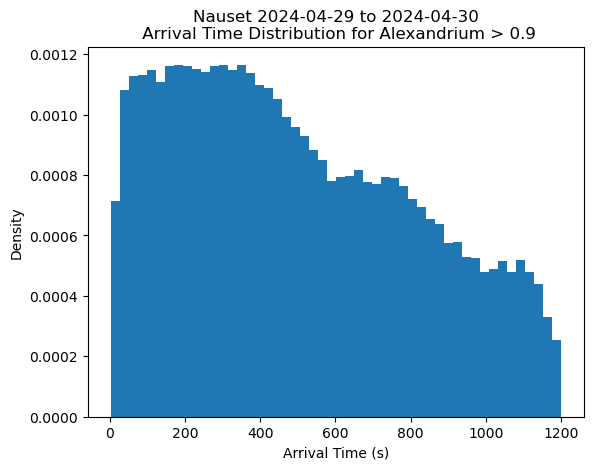

In [33]:
import matplotlib.pyplot as plt
plt.hist(alexfilt_df['RunTime'], bins=50, density=True)
plt.xlabel('Arrival Time (s)')
plt.ylabel('Density')
plt.title('Nauset 2024-04-29 to 2024-04-30\n Arrival Time Distribution for Alexandrium > 0.9')

KS statistic: 0.137
p-value: 0


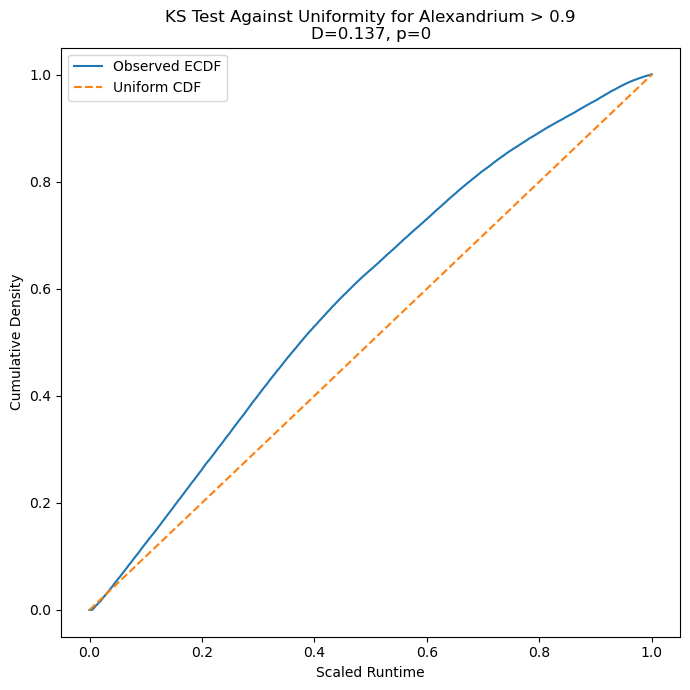

In [ ]:
Alex_ks, Alex_p = plot_single_runtime_cdf(alexfilt_df, "KS Test Against Uniformity for Alexandrium > 0.9")

## Chukchi Sea Bivalve larvae

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


## Some chat to scrape the data and get just the images identified as bivalve larvae 

from pathlib import Path
import pandas as pd

# -----------------------------
# User inputs
# -----------------------------
roi_csv = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/tag_class_roi_table_shellfishlarvae.csv")        # CSV with column: roi
data_dir = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/SKQ202310S/merged/")     # directory containing *_adc_only.csv files
output_csv = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/matched_roi_masterV2.csv")

roi_col = "roi"
target_celltag_col = "taglabel" 
roi_number_col = "RoiNumber"

# -----------------------------
# Load target ROIs
# -----------------------------
targets = pd.read_csv(roi_csv)

# Split ROI string into sample ID and ROI number
# Example: D20230727T033456_IFCB145_00036
targets["sample_id"] = targets[roi_col].str.rsplit("_", n=1).str[0]
targets["roi_number"] = targets[roi_col].str.rsplit("_", n=1).str[1].astype(int)

# Keep original search string as metadata
targets["original_search_criteria"] = targets[roi_col]
targets["taglabel"] = targets[target_celltag_col]

# -----------------------------
# Match ROIs across ADC files
# -----------------------------
matched_rows = []

for adc_file in data_dir.glob("*_adc_only.csv"):
    # Example filename:
    # D20230727T030526_IFCB145_adc_only.csv
    sample_id = adc_file.name.replace("_adc_only.csv", "")

    # Check whether this file contains any target ROIs
    file_targets = targets[targets["sample_id"] == sample_id]

    if file_targets.empty:
        continue

    df = pd.read_csv(adc_file)

    # Make sure RoiNumber is numeric
    df[roi_number_col] = df[roi_number_col].astype(int)

    # Merge to retain only matching ROI rows
    matched = df.merge(
        file_targets[["roi_number", "original_search_criteria", target_celltag_col]],
        left_on=roi_number_col,
        right_on="roi_number",
        how="inner"
    )

    # Add useful metadata
    matched["source_file"] = adc_file.name
    matched["sample_id"] = sample_id
    matched = matched.rename(columns={target_celltag_col: "taglabel"})

    # Drop helper column if desired
    matched = matched.drop(columns=["roi_number"])

    matched_rows.append(matched)

# -----------------------------
# Compile master dataframe
# -----------------------------
if matched_rows:
    master_df = pd.concat(matched_rows, ignore_index=True)
else:
    master_df = pd.DataFrame()

# Save output
master_df.to_csv(output_csv, index=False)

print(f"Matched {len(master_df)} rows")
print(f"Saved to {output_csv}")

Matched 308 rows
Saved to /Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/matched_roi_masterV2.csv


In [10]:
larvae_df = pd.read_csv(Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/matched_roi_masterV2.csv"))


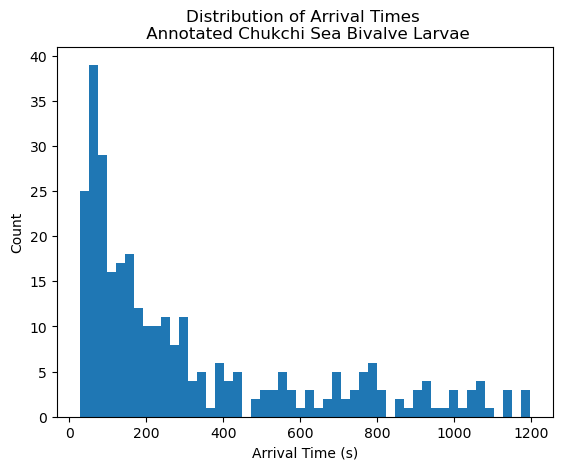

In [11]:
times = larvae_df["RunTime"].values
plt.hist(times, bins=50)
plt.xlabel("Arrival Time (s)")
plt.ylabel("Count")
plt.title("Distribution of Arrival Times \n Annotated Chukchi Sea Bivalve Larvae")
plt.show()


KS statistic: 0.436
p-value: 1.2e-53


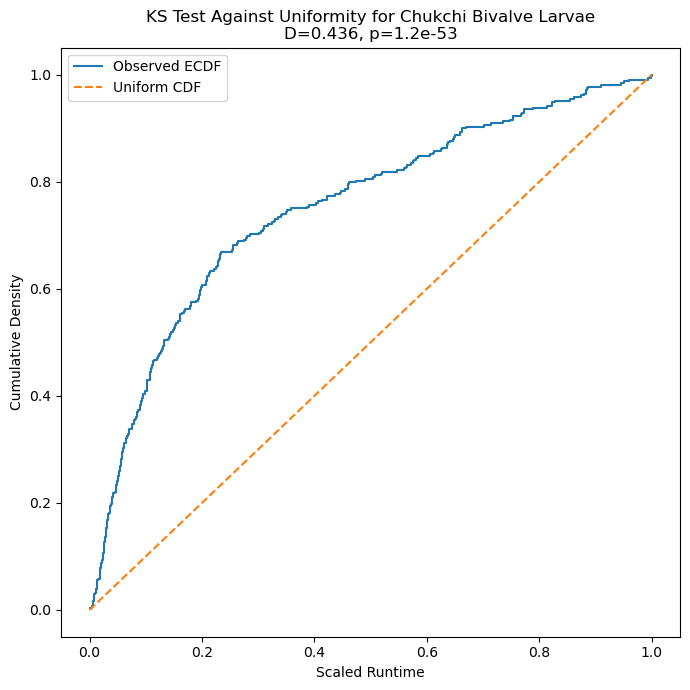

In [ ]:
chuk_ks, chuk_p = plot_single_runtime_cdf(larvae_df, "KS Test Against Uniformity for Chukchi Bivalve Larvae")

Loaded D20230727T070822_IFCB145_adc_only.csv: 1725 values
Loaded D20230727T081931_IFCB145_adc_only.csv: 1735 values
Loaded D20230727T062057_IFCB145_adc_only.csv: 1883 values
Loaded D20230727T084313_IFCB145_adc_only.csv: 1723 values
Loaded D20230727T125208_IFCB145_adc_only.csv: 6107 values
Loaded D20230727T030526_IFCB145_adc_only.csv: 2613 values
Loaded D20230727T035839_IFCB145_adc_only.csv: 2362 values
Loaded D20230727T122822_IFCB145_adc_only.csv: 6295 values
Loaded D20230727T055714_IFCB145_adc_only.csv: 2060 values
Loaded D20230727T044604_IFCB145_adc_only.csv: 2418 values
Loaded D20230727T120437_IFCB145_adc_only.csv: 6206 values
Loaded D20230727T042222_IFCB145_adc_only.csv: 2324 values
Loaded D20230727T102942_IFCB145_adc_only.csv: 8351 values
Loaded D20230727T033456_IFCB145_adc_only.csv: 2994 values
Loaded D20230727T105327_IFCB145_adc_only.csv: 3886 values
Loaded D20230727T100558_IFCB145_adc_only.csv: 5413 values
Loaded D20230727T090655_IFCB145_adc_only.csv: 1660 values
Loaded D202307

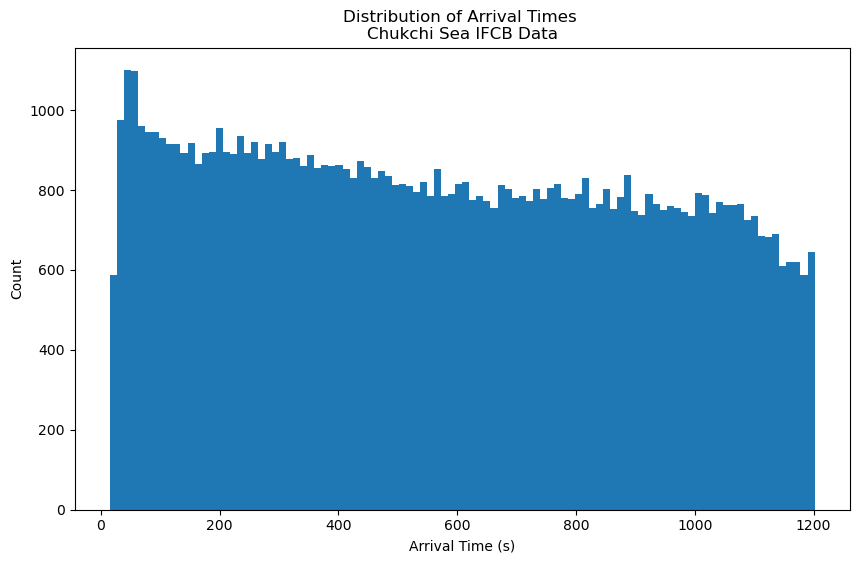

In [14]:

# -----------------------------
# User inputs
# -----------------------------
data_dir = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/Chukchi/SKQ202310S/merged/")

runtime_col = "RunTime"
file_pattern = "*adc_only.csv"

# -----------------------------
# Collect RunTime values
# -----------------------------
all_runtimes = []

for file in data_dir.glob(file_pattern):
    try:
        df = pd.read_csv(file, usecols=[runtime_col])

        # Convert to numeric and drop bad values
        runtimes = pd.to_numeric(df[runtime_col], errors="coerce").dropna()

        all_runtimes.append(runtimes)

        print(f"Loaded {file.name}: {len(runtimes)} values")

    except Exception as e:
        print(f"Skipping {file.name}: {e}")

# -----------------------------
# Combine into one Series
# -----------------------------
if all_runtimes:
    runtime_series = pd.concat(all_runtimes, ignore_index=True)
else:
    raise ValueError("No valid RunTime data found.")

print(f"\nTotal RunTime values: {len(runtime_series)}")

# -----------------------------
# Plot histogram
# -----------------------------
plt.figure(figsize=(10, 6))

plt.hist(runtime_series, bins=100)

plt.xlabel("Arrival Time (s)")
plt.ylabel("Count")
plt.title("Distribution of Arrival Times \nChukchi Sea IFCB Data")

#plt.tight_layout()
plt.show()

KS statistic: 0.039
p-value: 8.49e-109


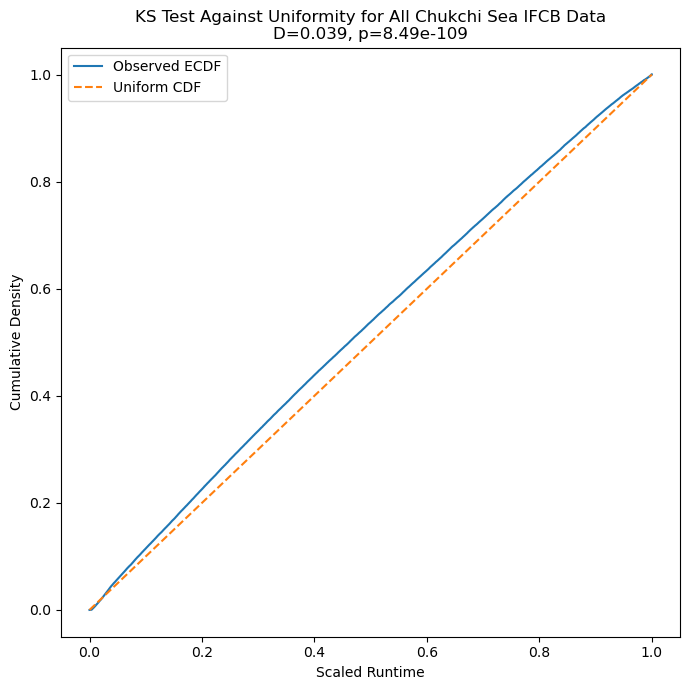

In [ ]:
chukALL_ks, chukALL_p = plot_single_runtime_cdf(runtime_series.to_frame(name="RunTime"), "KS Test Against Uniformity for All Chukchi Sea IFCB Data")

## Tripos GOM 2023

In [15]:
tripos_df = combine_csvs_with_filename("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/SeaTrac/radbot_ios/merged/")

In [23]:
tripos_filtered_df = filter_class("Tripos", tripos_df, alpha=0.9)
print(f"Master Df shape: {tripos_df.shape}")
print(f"Filtered Df shape: {tripos_filtered_df.shape}")

Master Df shape: (44953, 157)
Filtered Df shape: (2203, 157)


Text(0.5, 1.0, 'Arrival Time Distribution All IFCB IOS Data')

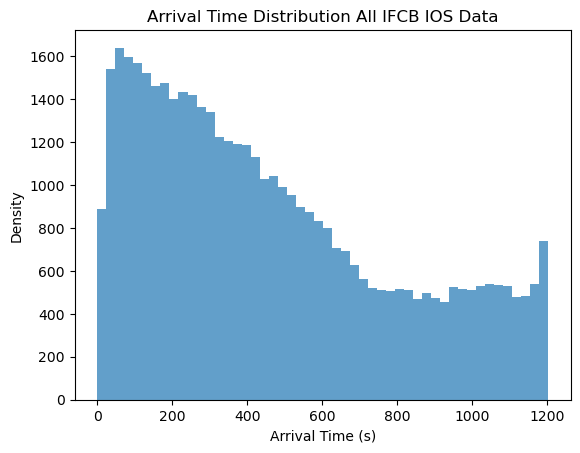

In [62]:
plt.hist(tripos_df['RunTime'], bins=50, alpha=0.7)
#plt.hist(tripos_filtered_df['RunTime'], bins=50, alpha=0.7)
plt.xlabel('Arrival Time (s)')
plt.ylabel('Density')
plt.title('Arrival Time Distribution All IFCB IOS Data')

KS statistic: 0.561
p-value: 0


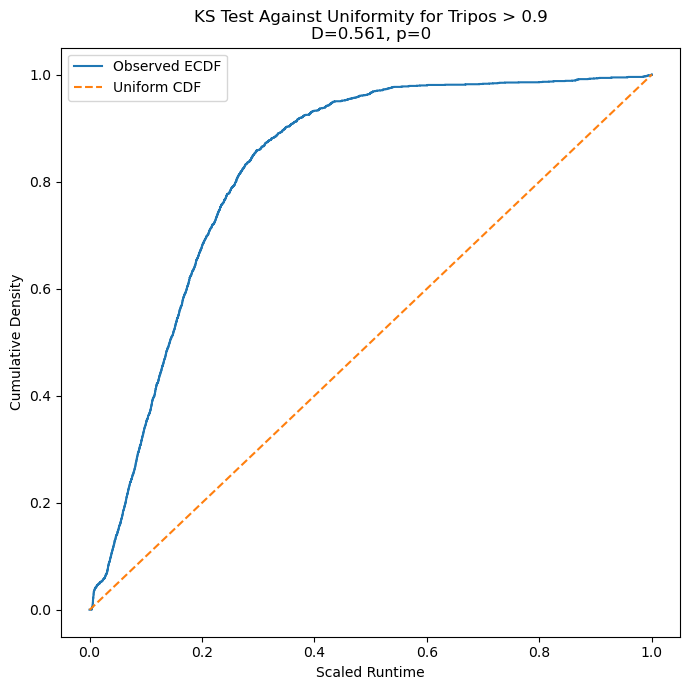

In [ ]:
tripos_ks, tripos_p = plot_single_runtime_cdf(tripos_filtered_df, "KS Test Against Uniformity for Tripos > 0.9")

## Grouped together

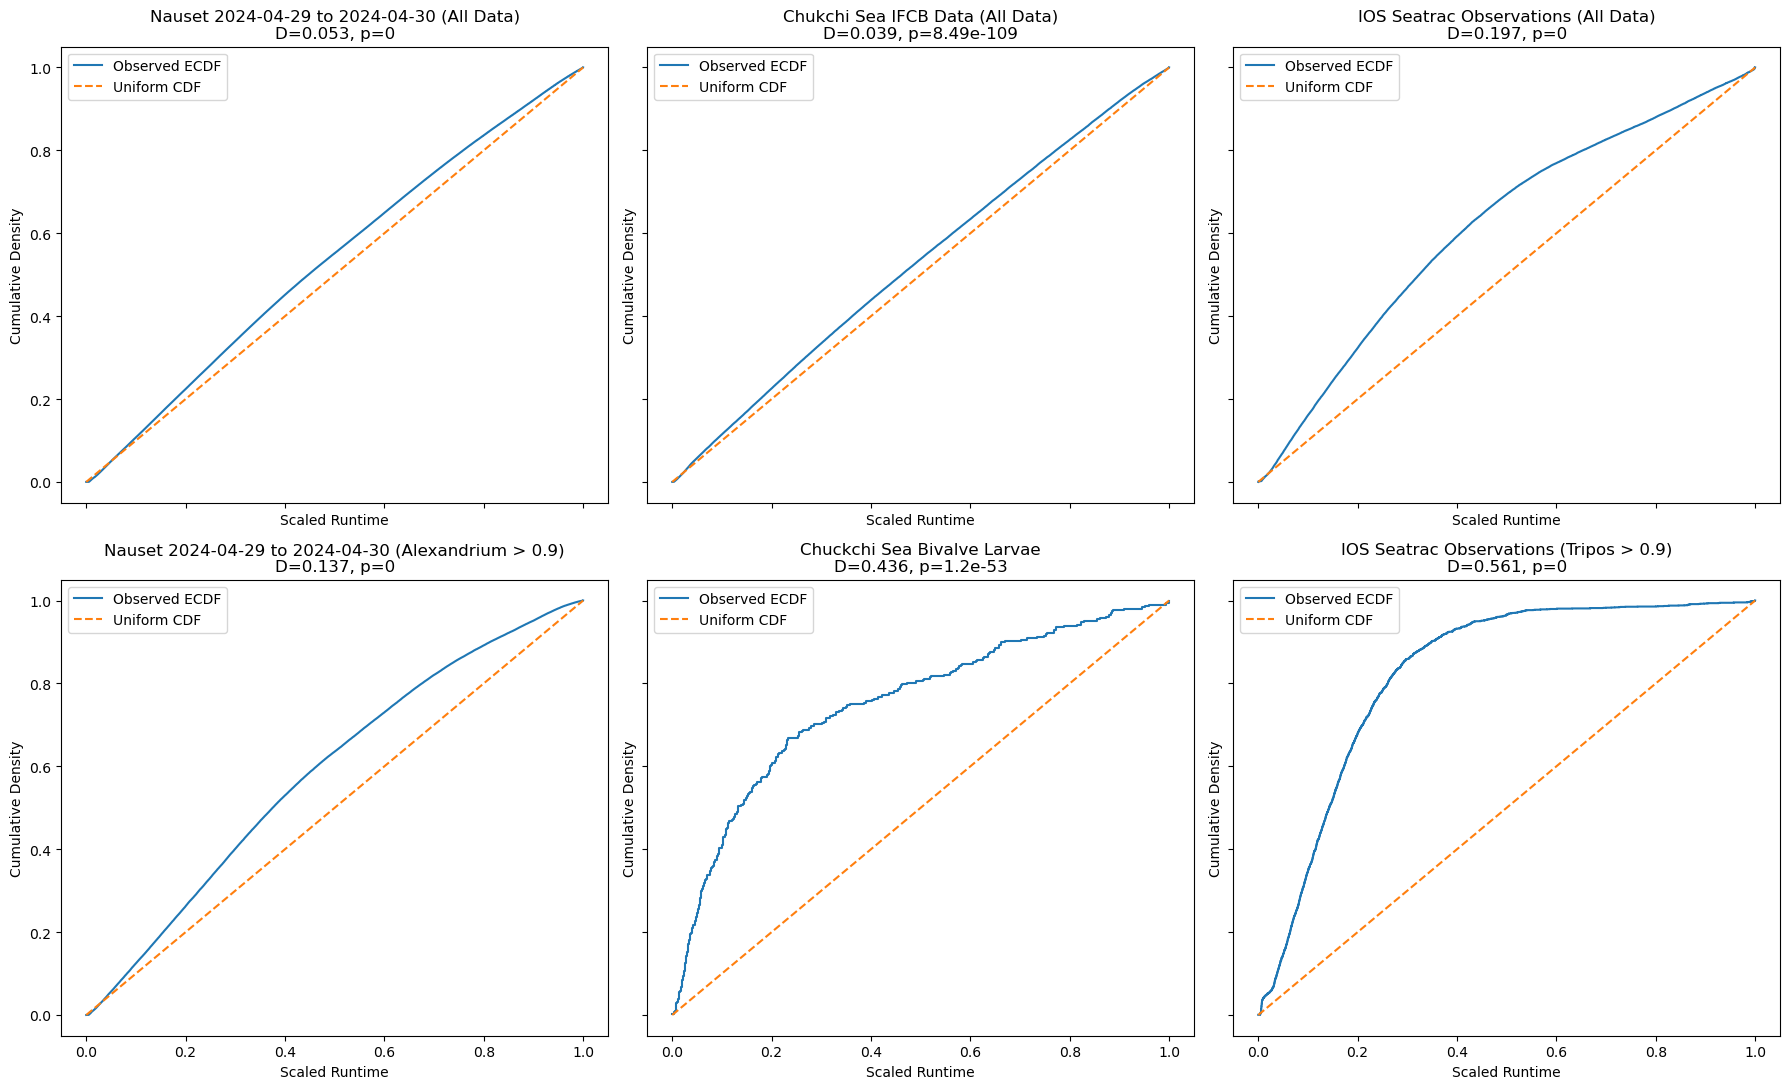

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11),
                         sharex=True, sharey=True)



plot_multi_runtime_cdf(master_df, axes[0, 0], "Nauset 2024-04-29 to 2024-04-30 (All Data)")
plot_multi_runtime_cdf(runtime_series.to_frame(name="RunTime"), axes[0, 1], "Chukchi Sea IFCB Data (All Data)")
plot_multi_runtime_cdf(tripos_df, axes[0, 2], "IOS Seatrac Observations (All Data)")
plot_multi_runtime_cdf(alexfilt_df, axes[1, 0], "Nauset 2024-04-29 to 2024-04-30 (Alexandrium > 0.9)")
plot_multi_runtime_cdf(larvae_df, axes[1, 1], "Chuckchi Sea Bivalve Larvae")
plot_multi_runtime_cdf(tripos_filtered_df, axes[1, 2], "IOS Seatrac Observations (Tripos > 0.9)")

# fig.supxlabel("Scaled Runtime", fontsize=14)
# fig.supylabel("Cumulative Density", fontsize=14)

plt.tight_layout()
plt.show()

Text(0.5, 0.01, 'Arrival Time (s)')

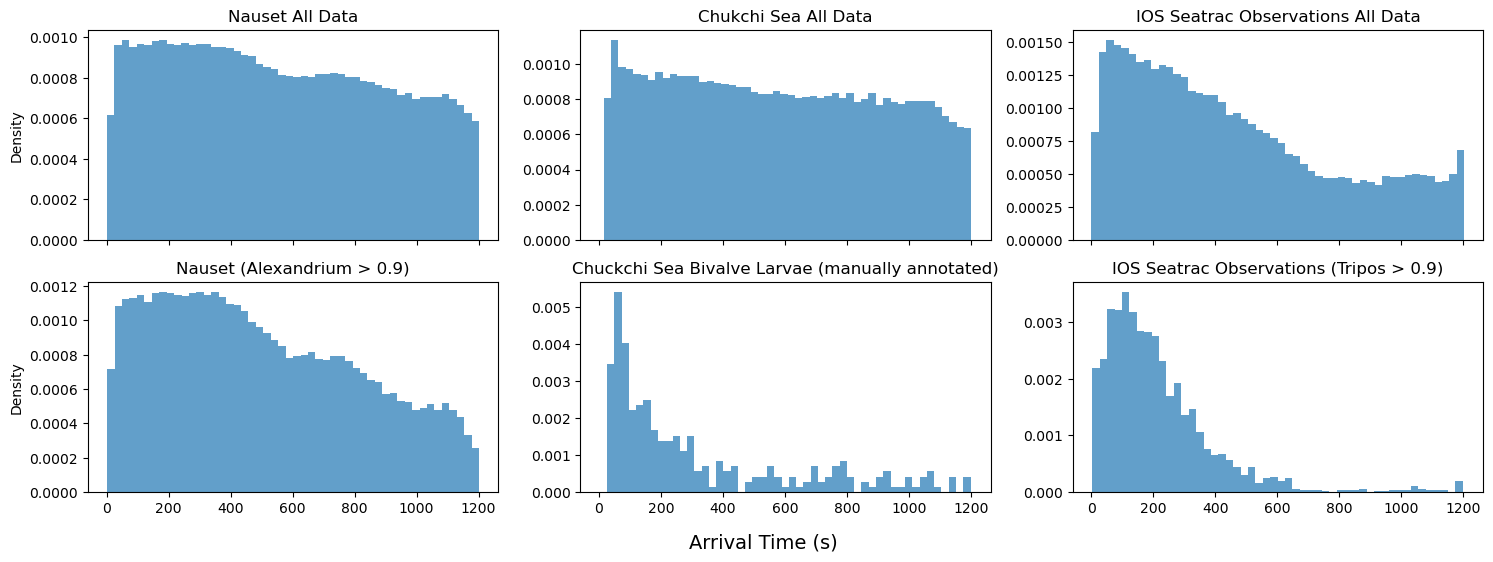

In [74]:
fig, ax = plt.subplots(2,3,figsize=(18, 6),
                       sharex=True, sharey=False)

ax[0, 0].hist(master_df['RunTime'], bins=50, alpha=0.7,density=True)
ax[0, 0].set_title('Nauset All Data')
#ax[0].set_xlabel('Arrival Time (s)')
ax[0, 0].set_ylabel('Density')

ax[0, 1].hist(runtime_series, bins=50, alpha=0.7,density=True)
ax[0, 1].set_title('Chukchi Sea All Data')
#ax[1].set_xlabel('Arrival Time (s)')
#ax[1].set_ylabel('Density')    

ax[0, 2].hist(tripos_df['RunTime'], bins=50, alpha=0.7,density=True)
ax[0, 2].set_title('IOS Seatrac Observations All Data')
#ax[2].set_xlabel('Arrival Time (s)')
#ax[2].set_ylabel('Density')

ax[1, 0].hist(alexfilt_df['RunTime'], bins=50, alpha=0.7,density=True)
ax[1, 0].set_title('Nauset (Alexandrium > 0.9)')
#ax[0].set_xlabel('Arrival Time (s)')
ax[1, 0].set_ylabel('Density')

ax[1, 1].hist(larvae_df['RunTime'], bins=50, alpha=0.7,density=True)
ax[1, 1].set_title('Chuckchi Sea Bivalve Larvae (manually annotated)')
#ax[1].set_xlabel('Arrival Time (s)')
#ax[1].set_ylabel('Density') 

ax[1, 2].hist(tripos_filtered_df['RunTime'], bins=50, alpha=0.7,density=True)
ax[1, 2].set_title('IOS Seatrac Observations (Tripos > 0.9)')
#ax[2].set_xlabel('Arrival Time (s)')
#ax[2].set_ylabel('Density') 

fig.supxlabel("Arrival Time (s)", fontsize=14)
#fig.supylabel("Density", fontsize=7)